# Compare Full-Trial ZV Results Across Selected Datasets

This notebook runs the same sync -> full-trial segment -> ZV threshold sweep pipeline for `0324_17_20`, `0325_16_57`, `0325_17_10`, and `0325_17_14_CSH`, then summarizes the captures together.


In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

for candidate in [
    Path.cwd().resolve(),
    Path.cwd().resolve() / "pyshoe_CSH",
    Path.cwd().resolve().parent / "pyshoe_CSH",
    Path("/home/user/soccer_analysis/pyshoe_CSH"),
]:
    if (candidate / "ins_tools").exists():
        NOTEBOOK_DIR = candidate
        break
else:
    raise FileNotFoundError("Could not locate pyshoe_CSH from the current working directory.")

PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from optitrack_sync import export_sync_results, make_full_trial_segment, sync_imu_optitrack_trial
from segment_zv_compare import analyze_segment, select_best_per_segment, sweep_all_segments

DATASETS = [
    {
        "name": "0324_17_20",
        "imu_file": "LOG00006.CSV",
        "opti_file": "Take 2026-03-24 05.20.13 PM.csv",
        "marker_ids": ["C7D50", "C7D60"],
    },
    {
        "name": "0325_16_57",
        "imu_file": "LOG00008.CSV",
        "opti_file": "Take 2026-03-25 04.57.59 PM.csv",
        "marker_ids": ["C7FA0"],
    },
    {
        "name": "0325_17_10",
        "imu_file": "LOG00010.CSV",
        "opti_file": "Take 2026-03-25 05.10.27 PM.csv",
        "marker_ids": ["C8530"],
    },
    {
        "name": "0325_17_14_CSH",
        "imu_file": "LOG00012.CSV",
        "opti_file": "Take 2026-03-25 05.14.27 PM.csv",
        "marker_ids": ["C89D0"],
    },
]

SYNC_CONFIG = {
    "imu_baseline_sec": 0.5,
    "opti_baseline_sec": 1.0,
    "search_window_sec": 8.0,
    "imu_rolling_samples": 11,
    "opti_rolling_samples": 7,
    "threshold_n_mad": 8.0,
    "refine_window_sec": (-0.6, 2.0),
    "max_refine_shift_sec": 1.0,
    "lag_window_sec": 12.0,
    "lag_step_sec": 10.0,
    "lag_max_shift_sec": 1.5,
    "linear_fit_method": "global",
}

FULL_TRIAL_CONFIG = {
    "time_col": "time_synced_to_imu",
    "pos_smooth_samples": 241,
    "vel_smooth_samples": 121,
    "min_speed_mps": 0.08,
    "segment_id": 1,
    "direction_label": "full_trial",
}

# ATTITUDE_SOURCE = 'gyro_integrated'
ATTITUDE_SOURCE = "measured_quat"
ACC_SOURCE = "raw_acc"
QUAT_MODE = "direct"
HORIZONTAL_MIRROR_MODE = "auto"
SELECTION_METRIC = "path_xz_error_m"
# SELECTION_METRIC = "armse_2d_m"

DETECTOR_GRIDS = {
    "shoe": np.geomspace(1e4, 3e7, 12),
    "ared": np.linspace(0.1, 4.0, 12),
    "amvd": np.geomspace(1e-3, 1e2, 12),
    "mbgtd": np.geomspace(1e-1, 1e2, 12),
}
WINDOW_SIZE = 5
SIGMA_A = 0.01
SIGMA_W_DPS = 0.1
ALIGN_DIST_M = 0.8
TIME_COLUMN = FULL_TRIAL_CONFIG["time_col"]

RESULTS_DIR = NOTEBOOK_DIR / "results" / f"full_trial_zv_compare_multi_{ATTITUDE_SOURCE}_{ACC_SOURCE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"RESULTS_DIR: {RESULTS_DIR}")
display(pd.DataFrame(DATASETS))


RESULTS_DIR: /home/user/soccer_analysis/pyshoe_CSH/results/full_trial_zv_compare_multi_measured_quat_raw_acc


,name,imu_file,opti_file,marker_ids
0,0324_17_20,LOG00006.CSV,Take 2026-03-24 05.20.13 PM.csv,"[C7D50, C7D60]"
1,0325_16_57,LOG00008.CSV,Take 2026-03-25 04.57.59 PM.csv,[C7FA0]
2,0325_17_10,LOG00010.CSV,Take 2026-03-25 05.10.27 PM.csv,[C8530]
3,0325_17_14_CSH,LOG00012.CSV,Take 2026-03-25 05.14.27 PM.csv,[C89D0]


In [12]:
dataset_results = {}
comparison_rows = []

for ds in DATASETS:
    dataset_name = ds["name"]
    data_dir = PROJECT_ROOT / "data" / "optitrack_imu" / dataset_name
    dataset_results_dir = RESULTS_DIR / dataset_name
    dataset_results_dir.mkdir(parents=True, exist_ok=True)

    imu_path = data_dir / ds["imu_file"]
    opti_path = data_dir / ds["opti_file"]

    sync_result = sync_imu_optitrack_trial(
        imu_path=imu_path,
        opti_path=opti_path,
        marker_ids=ds["marker_ids"],
        **SYNC_CONFIG,
    )

    imu = sync_result["imu"]
    opti_ankle = sync_result["opti_ankle"]
    summary = sync_result["summary"]
    local_lag_df = sync_result["local_lag_df"]
    local_lag_df_linear = sync_result["local_lag_df_linear"]

    sync_imu_out = data_dir / f"{imu_path.stem}_with_sync_signal.csv"
    sync_opti_out = data_dir / f"{opti_path.stem}_ankle_synced.csv"
    sync_summary_out = data_dir / "sync_summary.csv"
    sync_lag_out = data_dir / "sync_window_lags.csv"
    export_sync_results(
        imu_df=imu,
        opti_df=opti_ankle,
        summary=summary,
        local_lag_df=local_lag_df,
        local_lag_df_linear=local_lag_df_linear,
        imu_output_path=sync_imu_out,
        opti_output_path=sync_opti_out,
        summary_output_path=sync_summary_out,
        lag_output_path=sync_lag_out,
    )

    opti_ankle, full_trial_summary_df, imu_segment_df, opti_segment_df = make_full_trial_segment(
        imu_df=imu,
        opti_df=opti_ankle,
        **FULL_TRIAL_CONFIG,
    )

    full_trial_summary_out = data_dir / "full_trial_segment_summary.csv"
    full_trial_segments_dir = data_dir / "full_trial_segments"
    full_trial_segments_dir.mkdir(parents=True, exist_ok=True)
    imu_segment_path = full_trial_segments_dir / "segment_01_full_trial_imu.csv"
    opti_segment_path = full_trial_segments_dir / "segment_01_full_trial_opti.csv"

    full_trial_summary_df.to_csv(full_trial_summary_out, index=False)
    imu_segment_df.to_csv(imu_segment_path, index=False)
    opti_segment_df.to_csv(opti_segment_path, index=False)

    segment_table = pd.DataFrame(
        [
            {
                "segment_id": int(full_trial_summary_df.iloc[0]["segment_id"]),
                "direction_label": str(full_trial_summary_df.iloc[0]["direction_label"]),
                "imu_path": str(imu_segment_path),
                "opti_path": str(opti_segment_path),
            }
        ]
    )

    metrics_df = sweep_all_segments(
        segment_table=segment_table,
        detector_grids=DETECTOR_GRIDS,
        window_size=WINDOW_SIZE,
        sigma_a=SIGMA_A,
        sigma_w_dps=SIGMA_W_DPS,
        align_dist_m=ALIGN_DIST_M,
        time_column=TIME_COLUMN,
        attitude_source=ATTITUDE_SOURCE,
        quat_mode=QUAT_MODE,
        acc_source=ACC_SOURCE,
        horizontal_mirror_mode=HORIZONTAL_MIRROR_MODE,
    )
    metrics_df["abs_path_xz_error_m"] = metrics_df["path_xz_error_m"].abs()
    metrics_df["abs_disp_xz_error_m"] = metrics_df["disp_xz_error_m"].abs()

    best_df = select_best_per_segment(metrics_df, metric=SELECTION_METRIC)
    best_armse_df = select_best_per_segment(metrics_df, metric="armse_2d_m")

    selected_metrics = best_df.iloc[0]
    selected_metrics_dict, selected_detail_df = analyze_segment(
        imu_path=imu_segment_path,
        opti_path=opti_segment_path,
        segment_id=int(selected_metrics["segment_id"]),
        direction_label=str(selected_metrics["direction_label"]),
        detector=str(selected_metrics["detector"]),
        threshold=float(selected_metrics["threshold"]),
        window_size=WINDOW_SIZE,
        sigma_a=SIGMA_A,
        sigma_w_dps=SIGMA_W_DPS,
        align_dist_m=ALIGN_DIST_M,
        time_column=TIME_COLUMN,
        attitude_source=ATTITUDE_SOURCE,
        quat_mode=QUAT_MODE,
        acc_source=ACC_SOURCE,
        horizontal_mirror_mode=HORIZONTAL_MIRROR_MODE,
    )

    metrics_df.to_csv(dataset_results_dir / "threshold_sweep.csv", index=False)
    best_df.to_csv(dataset_results_dir / f"best_by_{SELECTION_METRIC}.csv", index=False)
    best_armse_df.to_csv(dataset_results_dir / "best_by_armse_2d_m.csv", index=False)
    selected_detail_df.to_csv(
        dataset_results_dir / f"{selected_metrics_dict['segment_name']}_{selected_metrics_dict['detector']}_{ATTITUDE_SOURCE}_{ACC_SOURCE}_detail.csv",
        index=False,
    )

    best_armse = best_armse_df.iloc[0]
    full_trial_row = full_trial_summary_df.iloc[0]

    comparison_rows.append(
        {
            "dataset": dataset_name,
            "sync_corr_after_linear": summary["corr_after_linear_sync"],
            "start_time_s": full_trial_row["start_time_s"],
            "end_time_s": full_trial_row["end_time_s"],
            "duration_sec": full_trial_row["duration_sec"],
            "raw_gt_path_xz_m": full_trial_row["gt_path_xz_m"],
            "selected_detector": selected_metrics_dict["detector"],
            "selected_threshold": selected_metrics_dict["threshold"],
            "selected_applied_horizontal_mirror": selected_metrics_dict["applied_horizontal_mirror"],
            "selected_est_path_xz_m": selected_metrics_dict["est_path_xz_m"],
            "selected_gt_path_xz_m": selected_metrics_dict["gt_path_xz_m"],
            "selected_path_xz_error_m": selected_metrics_dict["path_xz_error_m"],
            "selected_armse_2d_m": selected_metrics_dict["armse_2d_m"],
            "selected_endpoint_xz_error_m": selected_metrics_dict["endpoint_xz_error_m"],
            "selected_zv_ratio": selected_metrics_dict["zv_ratio"],
            "best_armse_detector": best_armse["detector"],
            "best_armse_threshold": best_armse["threshold"],
            "best_armse_2d_m": best_armse["armse_2d_m"],
            "best_armse_path_xz_error_m": best_armse["path_xz_error_m"],
        }
    )

    dataset_results[dataset_name] = {
        "config": ds,
        "data_dir": data_dir,
        "results_dir": dataset_results_dir,
        "sync_result": sync_result,
        "full_trial_summary_df": full_trial_summary_df,
        "metrics_df": metrics_df,
        "best_df": best_df,
        "best_armse_df": best_armse_df,
        "selected_metrics": selected_metrics_dict,
        "selected_detail_df": selected_detail_df,
    }

comparison_df = pd.DataFrame(comparison_rows).sort_values("dataset").reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)

display(comparison_df.round(3))


,dataset,sync_corr_after_linear,start_time_s,end_time_s,duration_sec,raw_gt_path_xz_m,selected_detector,selected_threshold,selected_applied_horizontal_mirror,selected_est_path_xz_m,selected_gt_path_xz_m,selected_path_xz_error_m,selected_armse_2d_m,selected_endpoint_xz_error_m,selected_zv_ratio,best_armse_detector,best_armse_threshold,best_armse_2d_m,best_armse_path_xz_error_m
0,0324_17_20,0.887,8.107,248.184,240.077,73.896,ared,0.100,flip_x,73.335,73.679,-0.344,3.235,9.421,0.460,amvd,4.329,0.991,-45.291
1,0325_16_57,0.844,2.291,51.675,49.384,46.440,ared,1.518,none,46.295,46.318,-0.023,6.240,18.686,0.299,shoe,6997088.875,1.093,-40.939
2,0325_17_10,0.868,0.070,39.708,39.639,46.143,ared,0.455,flip_x,44.718,46.100,-1.381,0.979,4.100,0.093,shoe,380635.825,0.407,-3.672
3,0325_17_14_CSH,0.835,0.272,60.420,60.149,49.520,mbgtd,0.658,flip_x,49.406,49.371,0.036,3.523,10.751,0.030,ared,1.873,0.682,-10.943


In [13]:
display(
    comparison_df[
        [
            "dataset",
            "sync_corr_after_linear",
            "duration_sec",
            "raw_gt_path_xz_m",
            "selected_detector",
            "selected_threshold",
            "selected_applied_horizontal_mirror",
            "selected_est_path_xz_m",
            "selected_gt_path_xz_m",
            "selected_path_xz_error_m",
            "selected_armse_2d_m",
            "selected_endpoint_xz_error_m",
        ]
    ].round(3)
)

for dataset_name in comparison_df["dataset"]:
    print(dataset_name)
    display(dataset_results[dataset_name]["full_trial_summary_df"].round(3))


,dataset,sync_corr_after_linear,duration_sec,raw_gt_path_xz_m,selected_detector,selected_threshold,selected_applied_horizontal_mirror,selected_est_path_xz_m,selected_gt_path_xz_m,selected_path_xz_error_m,selected_armse_2d_m,selected_endpoint_xz_error_m
0,0324_17_20,0.887,240.077,73.896,ared,0.100,flip_x,73.335,73.679,-0.344,3.235,9.421
1,0325_16_57,0.844,49.384,46.440,ared,1.518,none,46.295,46.318,-0.023,6.240,18.686
2,0325_17_10,0.868,39.639,46.143,ared,0.455,flip_x,44.718,46.100,-1.381,0.979,4.100
3,0325_17_14_CSH,0.835,60.149,49.520,mbgtd,0.658,flip_x,49.406,49.371,0.036,3.523,10.751


0324_17_20


,segment_id,direction_label,start_idx,end_idx,start_frame,end_frame,start_time_s,end_time_s,duration_sec,min_speed_mps,n_opti_samples,n_imu_samples,median_motion_speed_mps,max_motion_speed_mps,gt_path_xz_m,gt_path_3d_m,gt_disp_xz_m,gt_disp_3d_m
0,1,full_trial,1009,29831,1009,29831,8.107,248.184,240.077,0.08,28823,23162,0.157,1.045,73.896,76.122,2.117,2.117


0325_16_57


,segment_id,direction_label,start_idx,end_idx,start_frame,end_frame,start_time_s,end_time_s,duration_sec,min_speed_mps,n_opti_samples,n_imu_samples,median_motion_speed_mps,max_motion_speed_mps,gt_path_xz_m,gt_path_3d_m,gt_disp_xz_m,gt_disp_3d_m
0,1,full_trial,312,6241,312,6241,2.291,51.675,49.384,0.08,5930,4766,0.849,1.061,46.44,47.328,0.286,0.287


0325_17_10


,segment_id,direction_label,start_idx,end_idx,start_frame,end_frame,start_time_s,end_time_s,duration_sec,min_speed_mps,n_opti_samples,n_imu_samples,median_motion_speed_mps,max_motion_speed_mps,gt_path_xz_m,gt_path_3d_m,gt_disp_xz_m,gt_disp_3d_m
0,1,full_trial,62,4821,62,4821,0.07,39.708,39.639,0.08,4760,3826,0.986,1.184,46.143,47.02,0.307,0.307


0325_17_14_CSH


,segment_id,direction_label,start_idx,end_idx,start_frame,end_frame,start_time_s,end_time_s,duration_sec,min_speed_mps,n_opti_samples,n_imu_samples,median_motion_speed_mps,max_motion_speed_mps,gt_path_xz_m,gt_path_3d_m,gt_disp_xz_m,gt_disp_3d_m
0,1,full_trial,66,7286,66,7286,0.272,60.42,60.149,0.08,7221,5806,0.734,0.942,49.52,50.619,0.029,0.029


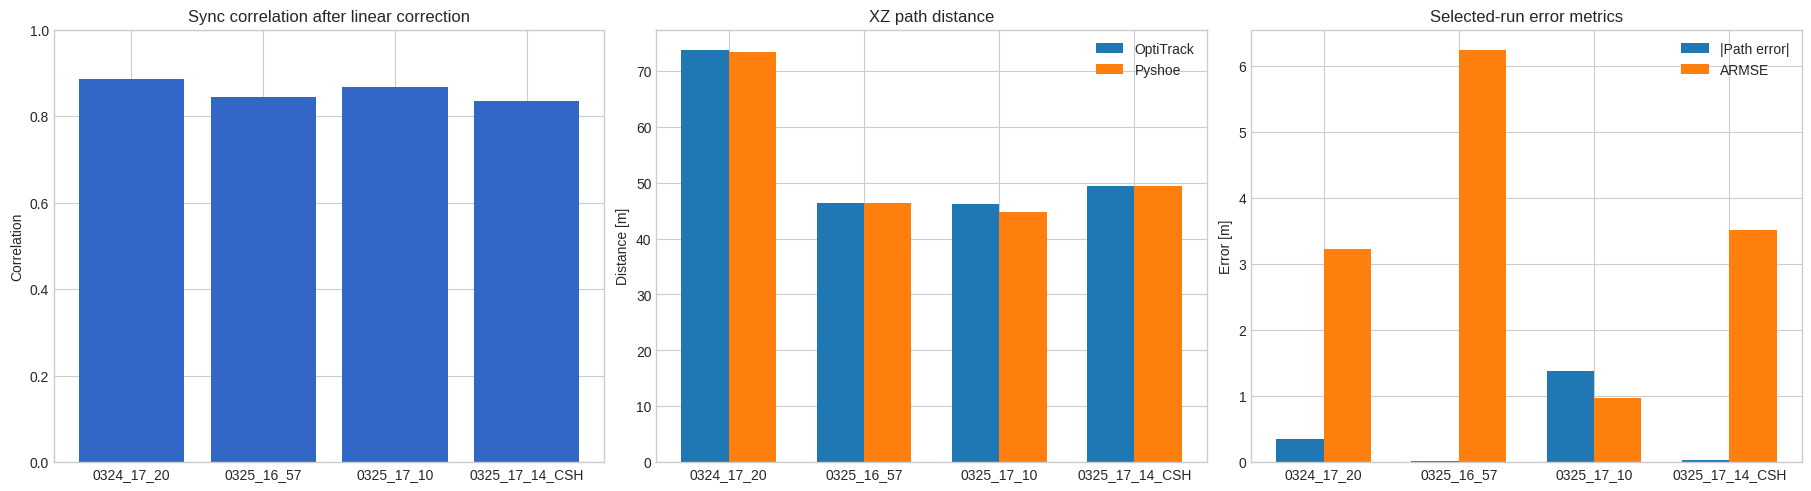

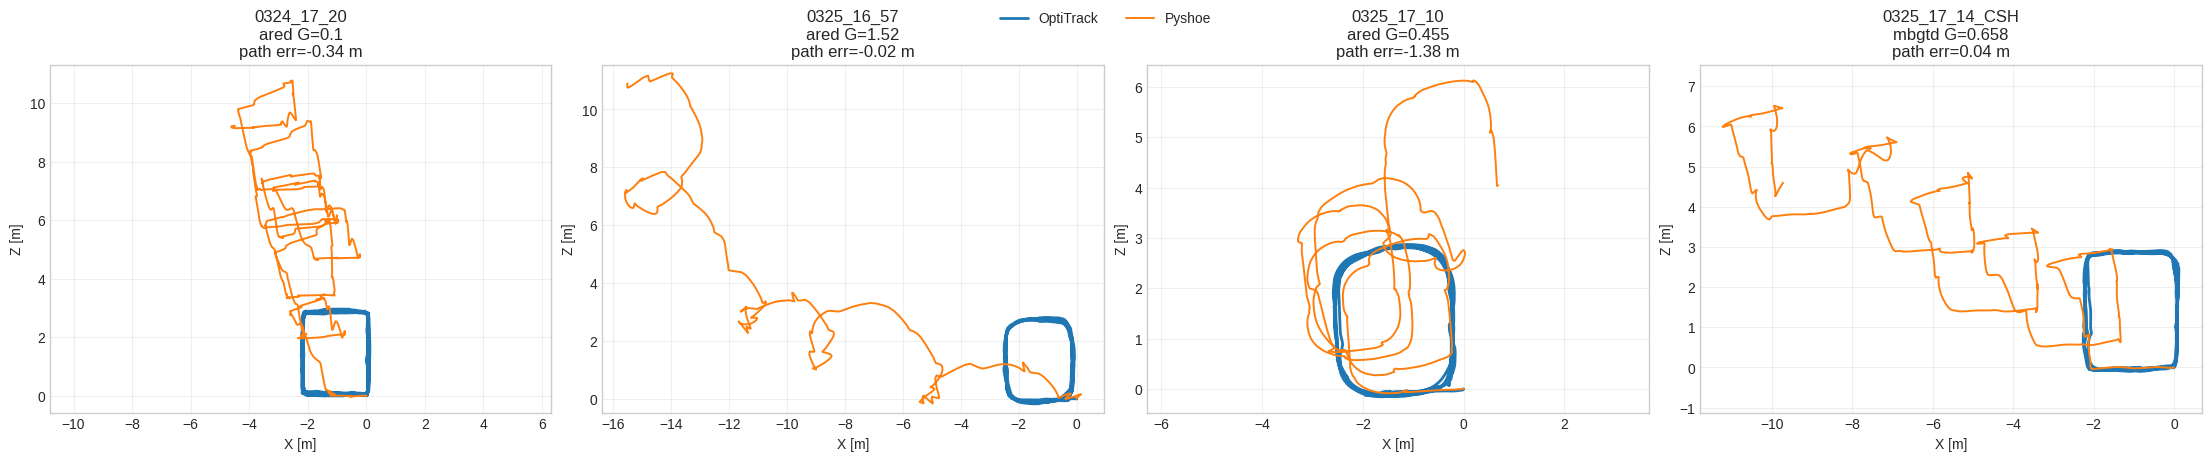

In [14]:
plot_df = comparison_df.copy()
x = np.arange(len(plot_df))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].bar(plot_df["dataset"], plot_df["sync_corr_after_linear"], color="#3267c8")
axes[0].set_title("Sync correlation after linear correction")
axes[0].set_ylabel("Correlation")
axes[0].set_ylim(0, 1)

axes[1].bar(x - width / 2, plot_df["selected_gt_path_xz_m"], width=width, label="OptiTrack")
axes[1].bar(x + width / 2, plot_df["selected_est_path_xz_m"], width=width, label="Pyshoe")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["dataset"])
axes[1].set_title("XZ path distance")
axes[1].set_ylabel("Distance [m]")
axes[1].legend()

axes[2].bar(x - width / 2, plot_df["selected_path_xz_error_m"].abs(), width=width, label="|Path error|")
axes[2].bar(x + width / 2, plot_df["selected_armse_2d_m"], width=width, label="ARMSE")
axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_df["dataset"])
axes[2].set_title("Selected-run error metrics")
axes[2].set_ylabel("Error [m]")
axes[2].legend()

plt.show()

fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.5 * len(DATASETS), 4.5), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, ds in zip(axes, DATASETS):
    dataset_name = ds["name"]
    detail_df = dataset_results[dataset_name]["selected_detail_df"]
    metrics = dataset_results[dataset_name]["selected_metrics"]
    ax.plot(detail_df["gt_x_m"], detail_df["gt_z_m"], label="OptiTrack", linewidth=2.0)
    ax.plot(detail_df["est_x_aligned_m"], detail_df["est_z_aligned_m"], label="Pyshoe", linewidth=1.4)
    ax.set_title(
        f"{dataset_name}\n"
        f"{metrics['detector']} G={metrics['threshold']:.3g}\n"
        f"path err={metrics['path_xz_error_m']:.2f} m"
    )
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Z [m]")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.show()


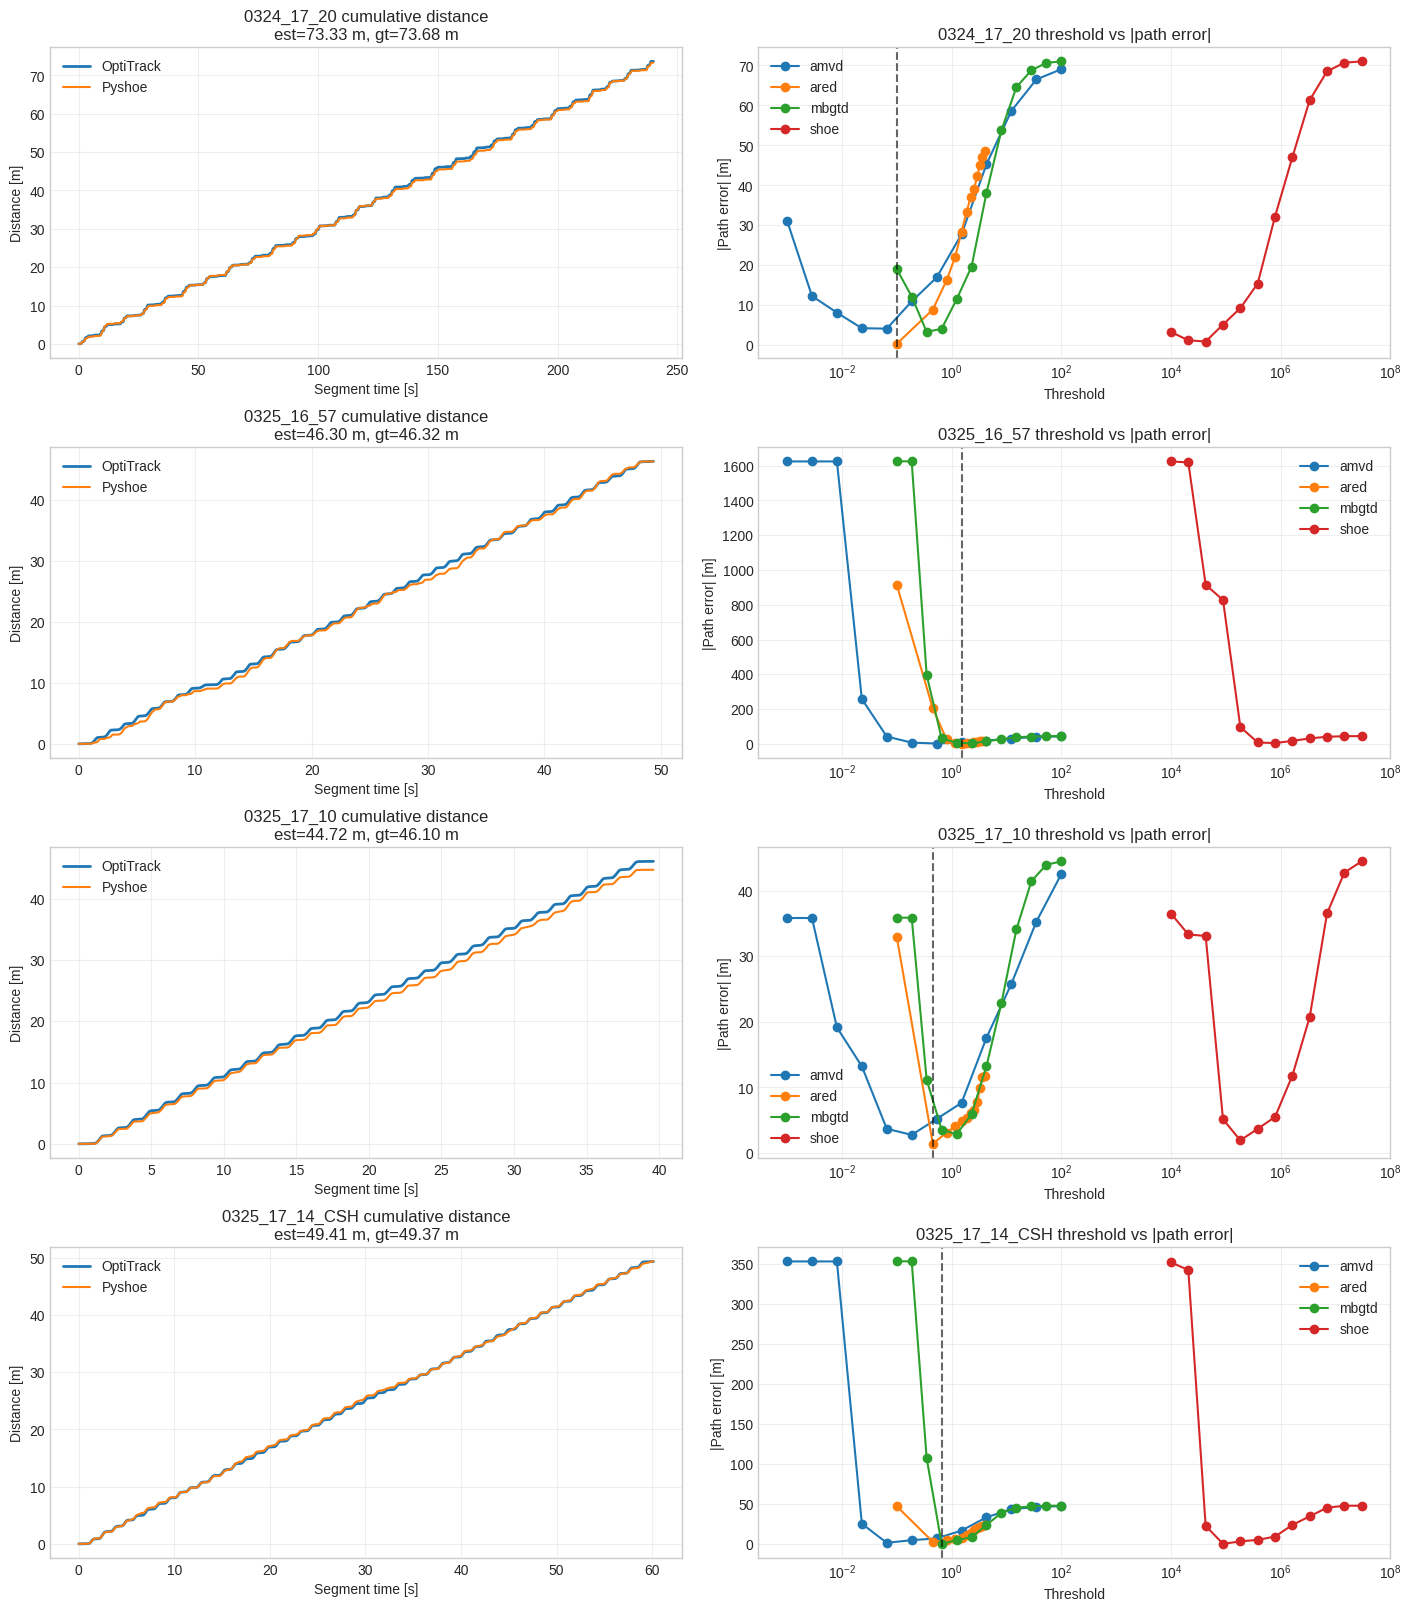

In [15]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 4.0 * len(DATASETS)), constrained_layout=True)
axes = np.atleast_2d(axes)

for row_idx, ds in enumerate(DATASETS):
    dataset_name = ds["name"]
    result = dataset_results[dataset_name]
    detail_df = result["selected_detail_df"]
    metrics = result["selected_metrics"]
    metrics_df = result["metrics_df"]

    axes[row_idx, 0].plot(detail_df["segment_time_s"], detail_df["gt_cumdist_xz_m"], label="OptiTrack", linewidth=2.0)
    axes[row_idx, 0].plot(detail_df["segment_time_s"], detail_df["est_cumdist_xz_m"], label="Pyshoe", linewidth=1.5)
    axes[row_idx, 0].set_title(
        f"{dataset_name} cumulative distance\n"
        f"est={metrics['est_path_xz_m']:.2f} m, gt={metrics['gt_path_xz_m']:.2f} m"
    )
    axes[row_idx, 0].set_xlabel("Segment time [s]")
    axes[row_idx, 0].set_ylabel("Distance [m]")
    axes[row_idx, 0].grid(True, alpha=0.3)
    axes[row_idx, 0].legend(loc="upper left")

    for detector, group in metrics_df.groupby("detector"):
        group = group.sort_values("threshold")
        axes[row_idx, 1].plot(group["threshold"], group["abs_path_xz_error_m"], marker="o", label=detector)
    axes[row_idx, 1].axvline(metrics["threshold"], color="black", linestyle="--", alpha=0.6)
    axes[row_idx, 1].set_xscale("log")
    axes[row_idx, 1].set_title(f"{dataset_name} threshold vs |path error|")
    axes[row_idx, 1].set_xlabel("Threshold")
    axes[row_idx, 1].set_ylabel("|Path error| [m]")
    axes[row_idx, 1].grid(True, alpha=0.3)
    axes[row_idx, 1].legend(loc="best")

plt.show()
